In [2]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# Dataset

Stima rozza della Frazione di eventi attribuibili ad AmBe

In [3]:
# Read the standard and AMBE datasets from parquet files
df_AMBE = pd.read_parquet('/Volumes/Oppedix_SSD/Dataframe_creator_run_5/Ambe_HighGain/combined_filtered_NO_RED.parquet')
df_STD = pd.read_parquet('/Volumes/Oppedix_SSD/AMBE5_DATA/std_runs_near_HG/nored_combined_filtered.parquet')



In [4]:
# Print max and min run numbers for both datasets
print(f"AMBE max run: {df_AMBE['run'].max()}, min run: {df_AMBE['run'].min()}")
print(f"STD max run: {df_STD['run'].max()}, min run: {df_STD['run'].min()}")

#Check if there are missing run vlues between max and min
missing_runs_AMBE = set(range(df_AMBE['run'].min(), df_AMBE['run'].max() + 1)) - set(df_AMBE['run'])
missing_runs_STD = set(range(df_STD['run'].min(), df_STD['run'].max() + 1)) - set(df_STD['run'])
print(f"Missing runs in AMBE: {missing_runs_AMBE}")
print(f"Missing runs in STD: {missing_runs_STD}")

AMBE max run: 100023, min run: 99266
STD max run: 100999, min run: 100032
Missing runs in AMBE: {99328, 99846, 99335, 99853, 99342, 99860, 99349, 99867, 99356, 99874, 99363, 99881, 99370, 99888, 99377, 99895, 99384, 99902, 99391, 99909, 99916, 99405, 99923, 99412, 99419, 99426, 99944, 99433, 99951, 99440, 99447, 99965, 99454, 99972, 99461, 99979, 99475, 99993, 99482, 100000, 99489, 100007, 99496, 100014, 99503, 100021, 99510, 99517, 99524, 99531, 99538, 99545, 99559, 99566, 99573, 99587, 99594, 99601, 99608, 99615, 99622, 99629, 99643, 99650, 99657, 99664, 99671, 99678, 99685, 99692, 99699, 99706, 99720, 99727, 99734, 99741, 99748, 99755, 99762, 99769, 99776, 99783, 99272, 99790, 99279, 99797, 99286, 99804, 99293, 99811, 99300, 99818, 99307, 99825, 99314, 99321, 99839}
Missing runs in STD: {100864, 100353, 100871, 100360, 100878, 100367, 100374, 100892, 100381, 100899, 100388, 100906, 100395, 100913, 100402, 100920, 100409, 100927, 100416, 100934, 100423, 100941, 100430, 100948, 100437

In [5]:
# Store both conversion factors as constants
CONVERSION_FACTOR_AMBE = 0.000577090214042
CONVERSION_FACTOR_STD = 0.000512964171610

# Store both exposure factors as constants
EXPOSURE_FACTOR_AMBE = 246085
EXPOSURE_FACTOR_STD = 351430 # 343271 se togli le run escluse con i quality cuts, ma non credo vada fatto



In [6]:
#Add sc_integral*conversion_factor and sc_integral/sc_nhits to both dataframes
df_AMBE['sc_en_calib'] = df_AMBE['sc_integral'] * CONVERSION_FACTOR_AMBE
df_AMBE['rho'] = df_AMBE['sc_en_calib'] / df_AMBE['sc_nhits']
df_STD['sc_en_calib'] = df_STD['sc_integral'] * CONVERSION_FACTOR_STD
df_STD['rho'] = df_STD['sc_en_calib'] / df_STD['sc_nhits']
df_AMBE['rho_from_sc'] = df_AMBE['sc_integral'] / df_AMBE['sc_nhits']
df_STD['rho_from_sc'] = df_STD['sc_integral'] / df_STD['sc_nhits']

   

In [7]:
# Print the total number of events in both datasets
print(f"Total events in AMBE: {len(df_AMBE)}")
print(f"Total events in STD: {len(df_STD)}")

#Print the total number of events in both dataaset nornalized by exposure
print(f"Total events in AMBE normalized by exposure: {len(df_AMBE)/EXPOSURE_FACTOR_AMBE}")
print(f"Total events in STD normalized by exposure: {len(df_STD)/EXPOSURE_FACTOR_STD}")




Total events in AMBE: 169117
Total events in STD: 202158
Total events in AMBE normalized by exposure: 0.6872300221468192
Total events in STD normalized by exposure: 0.5752440030731583


In [8]:
import numpy as np
from matplotlib.path import Path

def polygon_path(points):
    """
    points: sequence of (x_keV, y_keV_per_hit).
    Returns a closed matplotlib Path in data coordinates.
    """
    pts = np.asarray(points, dtype=float)
    if pts.shape[0] < 3:
        raise ValueError("Polygon needs at least 3 points.")
    # close polygon if not closed
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])
    # build corresponding Path codes
    codes = np.full(len(pts), Path.LINETO, dtype=Path.code_type)
    codes[0] = Path.MOVETO
    return Path(pts, codes)

def points_in_polygon_mask(x, y, poly_path):
    """
    x, y: 1D arrays (same length). poly_path: Path in data coords.
    Returns boolean mask of points strictly inside the polygon (no border).
    """
    xy = np.column_stack([x, y])
    mask = poly_path.contains_points(xy)
    # treat NaNs as outside
    bad = ~np.isfinite(x) | ~np.isfinite(y)
    mask[bad] = False
    return mask


10 000 * CONVERSION_FACTOR_AMBE: 5.77090214042
10 000 * CONVERSION_FACTOR_STD: 5.129641716099999


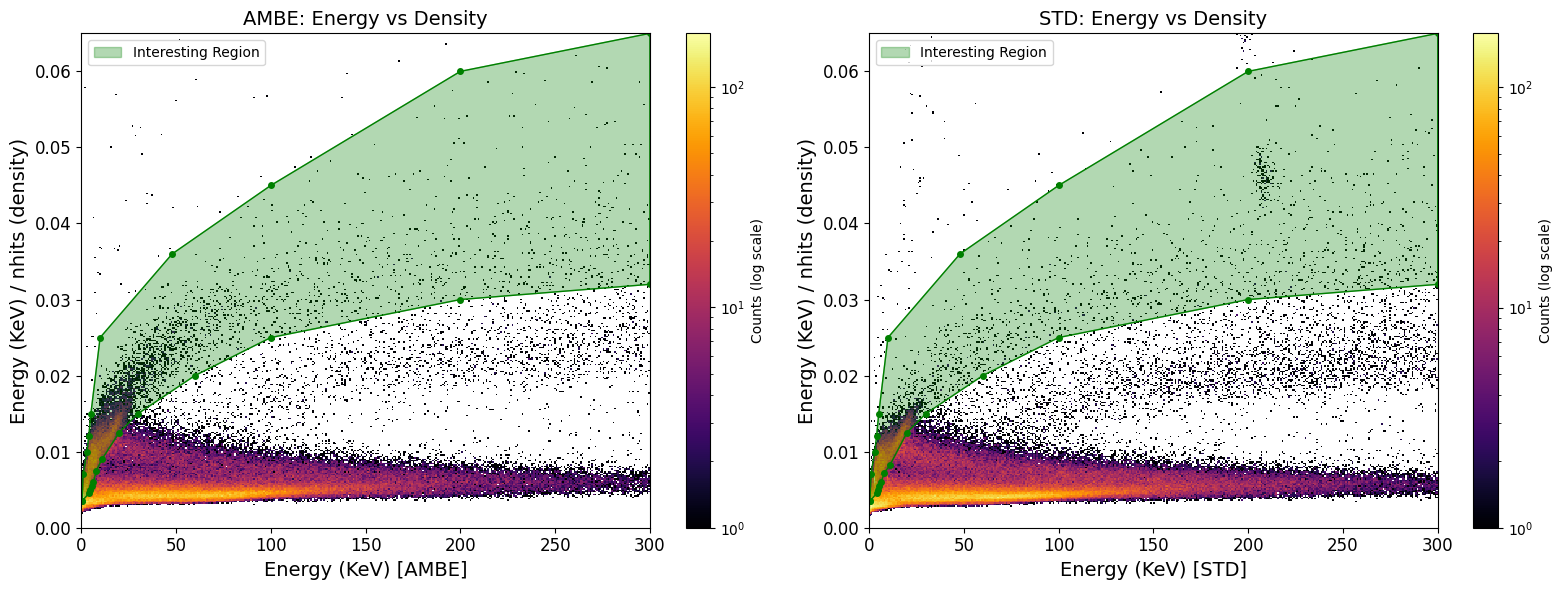

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# AMBE dataset
energy_AMBE  = df_AMBE["sc_integral"] * CONVERSION_FACTOR_AMBE
nhits_AMBE   = df_AMBE["sc_nhits"]
density_AMBE =  energy_AMBE / nhits_AMBE

#Print 10 000 * conversion factors
print(f"10 000 * CONVERSION_FACTOR_AMBE: {10000 * CONVERSION_FACTOR_AMBE}")
print(f"10 000 * CONVERSION_FACTOR_STD: {10000 * CONVERSION_FACTOR_STD}")

# STD dataset
energy_STD  = df_STD["sc_integral"] * CONVERSION_FACTOR_STD
nhits_STD   = df_STD["sc_nhits"]
density_STD = energy_STD / nhits_STD

plt.figure(figsize=(16, 6))

# AMBE
plt.subplot(1, 2, 1)
plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 300), (0, 0.065))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')

# Highlight slanted band + E>22000 region
poly_AMBE = [
    (0.5, 0.0035),
    (1, 0.007),
    (3, 0.010),
    (4, 0.012),
    (5.13, 0.015),
    ( 10.0, 0.025),
    (48.0, 0.036),
    ( 100.0, 0.045),
    ( 200.0, 0.060),
    ( 300.0, 0.065),
    ( 300.0, 0.032),
    ( 200.0, 0.03),
    ( 100.0, 0.025),
    ( 60.0, 0.02),
    ( 30.0, 0.015),
    ( 20.0, 0.0125),
    (11, 0.009),
    (8.0, 0.0075),
    (6.5, 0.006),
    (5.5, 0.0055),
    (4.5, 0.005),
    (4, 0.0045),
]
path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

#add horizontal space between the two plots
plt.subplots_adjust(wspace=0.3)

# STD
plt.subplot(1, 2, 2)
plt.hist2d(
    energy_STD,
    density_STD,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 300), (0, 0.065))
)
plt.xlabel("Energy (KeV) [STD]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("STD: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')

poly_STD = [
    (0.5, 0.0035),
    (1, 0.007),
    (3, 0.010),
    (4, 0.012),
    (5.13, 0.015),
    ( 10.0, 0.025),
    (48.0, 0.036),
    ( 100.0, 0.045),
    ( 200.0, 0.060),
    ( 300.0, 0.065),
    ( 300.0, 0.032),
    ( 200.0, 0.03),
    ( 100.0, 0.025),
    ( 60.0, 0.02),
    ( 30.0, 0.015),
    ( 20.0, 0.0125),
    (11, 0.0082),
    (8.0, 0.0072),
    (6.5, 0.006),
    (5.5, 0.0055),
    (4.5, 0.005),
    (4, 0.0045),
]
path_STD = polygon_path(poly_STD)

verts_STD = path_STD.vertices
plt.fill(verts_STD[:,0], verts_STD[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_STD[:,0], verts_STD[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')

plt.tight_layout()
#ticks font size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


In [11]:
# --- Count events in the interesting region ---
# AMBE mask & counts
mask_AMBE = points_in_polygon_mask(energy_AMBE.values, density_AMBE.values, path_AMBE)
n_events_AMBE = int(mask_AMBE.sum())
print(f"Number of events in polygon [AMBE]: {n_events_AMBE}")
print(f"Normalized by exposure [AMBE]: {n_events_AMBE/EXPOSURE_FACTOR_AMBE}")

# STD mask & counts
mask_STD = points_in_polygon_mask(energy_STD.values, density_STD.values, path_STD)
n_events_STD = int(mask_STD.sum())
print(f"Number of events in polygon [STD]: {n_events_STD}")
print(f"Normalized by exposure [STD]: {n_events_STD/EXPOSURE_FACTOR_STD}")


Number of events in polygon [AMBE]: 19067
Normalized by exposure [AMBE]: 0.07748135806733446
Number of events in polygon [STD]: 17323
Normalized by exposure [STD]: 0.04929288905329653


In [12]:
import numpy as np

# =========================
# Inputs (your originals)
# =========================
N_AMBE = n_events_AMBE                 # Total AMBE counts in the interesting region (Poisson)
E_AMBE = EXPOSURE_FACTOR_AMBE          # AMBE exposure (assumed exact here)
N_STD  = n_events_STD                  # Total STD counts in the interesting region (Poisson)
E_STD  = EXPOSURE_FACTOR_STD           # STD exposure (assumed exact here)

# Safety checks for divisions below
if N_AMBE <= 0:
    raise ValueError("N_AMBE must be > 0 to compute AF_e (excess / N_AMBE).")
if E_AMBE <= 0 or E_STD <= 0:
    raise ValueError("Exposures must be > 0.")
    
# =========================
# Rates (your originals)
# =========================
r_AMBE = N_AMBE / E_AMBE               # AMBE rate in region
r_STD  = N_STD  / E_STD                # STD  rate in region

# =========================
# Error on the rates (Poisson statistics) — your originals
# =========================
# For Poisson counts, Var(N) = N, so sigma_N = sqrt(N).
# Treating exposure as exact, the rate uncertainty is sigma_r = sqrt(N) / exposure.
sigma_r_AMBE = np.sqrt(N_AMBE) / E_AMBE
sigma_r_STD  = np.sqrt(N_STD)  / E_STD

# =========================
# Expected baseline during AMBE exposure and excess (your originals)
# =========================
# Baseline expectation (what we'd expect during AMBE exposure if there were NO AMBE effect):
# mu = r_STD * E_AMBE = (N_STD / E_STD) * E_AMBE = k * N_STD, where k := E_AMBE / E_STD
k  = E_AMBE / E_STD
mu = r_STD * E_AMBE                   # == k * N_STD

# Excess = observed AMBE counts - expected baseline counts
excess = N_AMBE - mu                  # X := A - mu

# =========================
# Uncertainties with proper covariance
# =========================
# We now compute variances and covariances in terms of the *primitive* Poisson variables:
#   A := N_AMBE ~ Poisson, Var(A) = A
#   S := N_STD  ~ Poisson, Var(S) = S
#   mu = k * S  => Var(mu) = k^2 * Var(S) = k^2 * S
#   excess X = A - mu = A - k S
#
# Key (in)dependences:
# - We assume A and S are independent (different runs). Therefore Cov(A, S) = 0.
# - mu depends on S only, not on A. So A ⟂ mu.
#
# From that:
#   Var(A)    = A
#   Var(mu)   = k^2 * S
#   Var(X)    = Var(A - mu) = Var(A) + Var(mu) - 2*Cov(A, mu) = A + k^2 * S (since Cov(A, mu)=0)
#   Cov(X, A) = Cov(A - mu, A) = Cov(A, A) - Cov(mu, A) = Var(A) - 0 = A
#   Cov(X, mu)= Cov(A - mu, mu) = Cov(A, mu) - Var(mu) = 0 - Var(mu) = -k^2 * S
#
# NOTE: These covariances are exactly what your previous code was missing. They matter because
# X contains A, so X and A are *not* independent; similarly, X and mu are anti-correlated.

A = N_AMBE
S = N_STD

Var_A   = A
Var_S   = S
Var_mu  = (k**2) * Var_S
Var_X   = Var_A + Var_mu            # A + k^2 S
Cov_XA  = Var_A                     # = A
Cov_Xmu = -Var_mu                   # = -k^2 S

# =========================
# Error on mu and excess (compatible with your original naming)
# =========================
# Your original sigma_mu was sigma_r_STD * E_AMBE; algebraically that's k*sqrt(S), i.e., sqrt(Var_mu), correct.
sigma_mu    = np.sqrt(Var_mu)       # = k * sqrt(S) = sigma_r_STD * E_AMBE
sigma_excess = np.sqrt(Var_X)       # = sqrt(A + k^2 S)

# =========================
# Percent of AMBE events attributable to AMBE (AF_e) — your original definition
# =========================
# AF_e = excess / N_AMBE = X / A
AF_e = excess / N_AMBE

# Proper uncertainty on AF_e with covariance:
# For f(X, A) = X/A,
#   ∂f/∂X = 1/A
#   ∂f/∂A = -X / A^2
# Var(f) ≈ (∂f/∂X)^2 Var(X) + (∂f/∂A)^2 Var(A) + 2 (∂f/∂X)(∂f/∂A) Cov(X, A)
#        = (1/A^2) Var_X + (X^2 / A^4) Var_A - 2 * (X / A^3) * Cov_XA
Var_AF_e = (Var_X / A**2) + (excess**2 * Var_A) / (A**4) - 2 * (excess * Cov_XA) / (A**3)
sigma_AF_e = np.sqrt(Var_AF_e)

print(f"Attributable fraction among AMBE (percent of AMBE events added by AMBE): {100*AF_e:.2f}% ± {100*sigma_AF_e:.2f}%")

# =========================
# Percent increase over baseline — your original definition
# =========================
# percent_increase = (excess / mu) * 100 = (X / mu) * 100
percent_increase = (excess / mu) * 100

# Proper uncertainty on (X / mu) with covariance:
# For g(X, mu) = X/mu,
#   ∂g/∂X   = 1/mu
#   ∂g/∂mu  = -X / mu^2
# Var(g) ≈ (1/mu^2) Var_X + (X^2 / mu^4) Var_mu + 2 * (1/mu) * (-X/mu^2) * Cov(X, mu)
#        = (Var_X / mu^2) + (X^2 Var_mu / mu^4) - 2 * (X / mu^3) * Cov_Xmu
# IMPORTANT: Cov_Xmu = -Var_mu, so the last term becomes + 2 * X * Var_mu / mu^3
Var_ratio_X_mu = (Var_X / mu**2) + (excess**2 * Var_mu) / (mu**4) - 2 * (excess * Cov_Xmu) / (mu**3)
sigma_percent_increase = 100.0 * np.sqrt(Var_ratio_X_mu)

print(f"Percent increase over baseline: {percent_increase:.2f}% ± {sigma_percent_increase:.2f}%")

# =========================
# “Per N_sample AMBE-region events, how many are added by AMBE?”
# =========================
# This is AF_e scaled by the sample size; propagate via sigma(AF_e) * N_sample.
N_sample = 10000
expected_added_per_sample = AF_e * N_sample
sigma_expected_added_per_sample = sigma_AF_e * N_sample

print(f"Expected AMBE-added events per {N_sample} AMBE-region events: "
      f"{expected_added_per_sample:.1f} ± {sigma_expected_added_per_sample:.1f}")

# =========================
# (Optional) Also print the raw excess with its SE, for completeness
# =========================
print(f"Difference of events (excess): {excess:.1f} ± {sigma_excess:.1f}")


Attributable fraction among AMBE (percent of AMBE events added by AMBE): 36.38% ± 0.67%
Percent increase over baseline: 57.19% ± 1.65%
Expected AMBE-added events per 10000 AMBE-region events: 3638.1 ± 66.8
Difference of events (excess): 6936.8 ± 166.0


In [13]:
import numpy as np

# ============================================
# Inputs: AF_e (fraction of AMBE events that are "added by AMBE") and its SE
# We try to read them from your session; if not found, we fall back to your printed values.
# ============================================
try:
    alpha = float(AF_e)                     # AF_e from your earlier cell (unitless, e.g., 0.32)
    sigma_alpha = float(sigma_AF_e)         # SE(AF_e) from your earlier cell (unitless)
except NameError:
    # Fallback to the numbers you printed:
    alpha = 0.32            # 32.00%
    sigma_alpha = 0.0095    # ±0.95 percentage points => ±0.0095 absolute

# Sanity checks
if not (0.0 <= alpha <= 1.0):
    raise ValueError("AF_e (alpha) must be between 0 and 1.")
if sigma_alpha < 0:
    raise ValueError("sigma_alpha must be non-negative.")

# --------------------------------------------
# Concept: Mixture model for CWOLA
# - STD sample is pure background:       p0(x) = B(x)
# - AMBE sample is a mixture:            p1(x) = alpha * S(x) + (1 - alpha) * B(x)
#   where alpha = AF_e is the fraction of 'true signal-like' (AMBE-added) events.
# A perfect classifier ranks by the likelihood ratio p1(x)/p0(x).
# The unavoidable overlap is the (1 - alpha) * B(x) inside AMBE, which is indistinguishable from STD.
# --------------------------------------------

# ============================================
# 1) ROC–AUC ceiling (assuming S vs B are perfectly separable)
#    Derivation:
#      AUC_max = P(score_positive > score_negative)
#              = alpha * 1.0  + (1 - alpha) * 0.5
#              = 0.5 + 0.5 * alpha
#    Uncertainty propagation (alpha is the only uncertain input):
#      sigma(AUC_max) = |dAUC/dalpha| * sigma_alpha = 0.5 * sigma_alpha
# ============================================
AUC_max = 0.5 + 0.5 * alpha
sigma_AUC_max = 0.5 * sigma_alpha

# ============================================
# 2) Accuracy ceiling under equal class priors
#    With balanced evaluation (same # of AMBE and STD events),
#    maximum accuracy equals:
#      Acc_max = 0.5 * (1 + TV(p1, p0)) ≤ 0.5 * (1 + alpha)
#    Under perfect S/B separability: TV(S,B) = 1 => Acc_max = 0.5 * (1 + alpha)
#    Uncertainty: sigma(Acc_max) = 0.5 * sigma_alpha
# ============================================
Acc_max_balanced = 0.5 * (1.0 + alpha)
sigma_Acc_max_balanced = 0.5 * sigma_alpha

# ============================================
# 3) “Zero-FPR operating point” ceiling (perfect precision slice)
#    If you demand FPR = 0, you can only accept truly signal-like events in AMBE.
#    That caps the achievable recall (TPR) by the available signal fraction:
#      TPR_max(FPR=0) = alpha
#      Precision at that point = 1.0
#    F1 at FPR=0:
#      F1_max = 2 * Precision * Recall / (Precision + Recall)
#             = 2 * 1 * alpha / (1 + alpha) = 2 alpha / (1 + alpha)
#    Uncertainty:
#      sigma(TPR_max) = sigma_alpha
#      dF1/dalpha = 2 / (1 + alpha)^2  =>  sigma(F1_max) = (2 / (1 + alpha)^2) * sigma_alpha
# ============================================
TPR0_max = alpha
sigma_TPR0_max = sigma_alpha

F1_at_FPR0 = 2.0 * alpha / (1.0 + alpha)
sigma_F1_at_FPR0 = (2.0 / (1.0 + alpha)**2) * sigma_alpha

# ============================================
# 4) Generalized ROC–AUC ceiling if S vs B are not perfectly separable
#    If AUC(S vs B) = AUC_SB (between 0.5 and 1.0), then:
#      AUC_max_general = 0.5 + alpha * (AUC_SB - 0.5)
#    (because only the alpha fraction can separate from B; the rest are background-vs-background ties)
#    We print this as a formula and also plug AUC_SB=1 for the “ideal S/B separability” case.
#    Uncertainty (holding AUC_SB fixed): sigma = |AUC_SB - 0.5| * sigma_alpha
# ============================================
def auc_ceiling_given_auc_sb(alpha, auc_sb, sigma_alpha=0.0):
    """Return AUC ceiling and its SE for a given AUC(S,B)=auc_sb."""
    auc = 0.5 + alpha * (auc_sb - 0.5)
    se  = abs(auc_sb - 0.5) * sigma_alpha
    return auc, se

AUC_max_if_SB_perfect, sigma_AUC_max_if_SB_perfect = auc_ceiling_given_auc_sb(alpha, 1.0, sigma_alpha)

# ============================================
# PRINTS: Detailed explanations with substitutions
# ============================================
print("=== Input mixture parameter ===")
print(f"AF_e (alpha): {alpha:.4f}  ± {sigma_alpha:.4f}  "
      f"({alpha*100:.2f}% ± {sigma_alpha*100:.2f}%)\n")

print("=== ROC–AUC ceiling (perfect S/B separability) ===")
print("Formula: AUC_max = 0.5 + 0.5 * alpha")
print(f"Substitution: AUC_max = 0.5 + 0.5 * {alpha:.4f} = {AUC_max:.3f}")
print(f"Uncertainty: sigma(AUC_max) = 0.5 * sigma_alpha = 0.5 * {sigma_alpha:.4f} = {sigma_AUC_max:.4f}\n")

print("=== Accuracy ceiling with equal class sizes ===")
print("Formula: Acc_max = 0.5 * (1 + alpha)  (upper bound when S and B are disjoint)")
print(f"Substitution: Acc_max = 0.5 * (1 + {alpha:.4f}) = {Acc_max_balanced:.3f}")
print(f"Uncertainty: sigma(Acc_max) = 0.5 * sigma_alpha = {sigma_Acc_max_balanced:.4f}\n")

print("=== Zero-FPR operating point (perfect precision slice) ===")
print("TPR_max(FPR=0) = alpha;   Precision = 1.0")
print(f"TPR_max = {TPR0_max:.4f} ± {sigma_TPR0_max:.4f}")
print("\nF1 at FPR=0:  F1 = 2 * alpha / (1 + alpha)")
print(f"Substitution: F1 = 2 * {alpha:.4f} / (1 + {alpha:.4f}) = {F1_at_FPR0:.3f}")
print(f"Uncertainty:  dF1/dalpha = 2 / (1 + alpha)^2  =>  sigma(F1) = {2/(1+alpha)**2:.4f} * sigma_alpha"
      f" = {sigma_F1_at_FPR0:.4f}\n")

print("=== Generalized ROC–AUC ceiling when S vs B are not perfectly separable ===")
print("Formula: AUC_max(alpha, AUC_SB) = 0.5 + alpha * (AUC_SB - 0.5)")
print("  • If AUC_SB = 1.0 (ideal S/B): reduces to 0.5 + 0.5*alpha (same as above).")
print("  • If AUC_SB < 1.0: ceiling drops linearly with (AUC_SB - 0.5).")
print(f"For AUC_SB = 1.0: AUC_max = {AUC_max_if_SB_perfect:.3f} ± {sigma_AUC_max_if_SB_perfect:.4f}")
print("You can plug your empirical AUC(S vs B) to get a tighter, realistic ceiling.\n")

# ===== Short TL;DR summary =====
print("TL;DR ceilings (with perfect S/B separability):")
print(f"  • ROC–AUC_max ≈ {AUC_max:.3f} ± {sigma_AUC_max:.3f}")
print(f"  • Accuracy_max (balanced) ≈ {Acc_max_balanced:.3f} ± {sigma_Acc_max_balanced:.3f}")
print(f"  • At FPR=0: TPR_max ≈ {TPR0_max:.3f} ± {sigma_TPR0_max:.3f}, "
      f"F1 ≈ {F1_at_FPR0:.3f} ± {sigma_F1_at_FPR0:.3f}")


=== Input mixture parameter ===
AF_e (alpha): 0.3638  ± 0.0067  (36.38% ± 0.67%)

=== ROC–AUC ceiling (perfect S/B separability) ===
Formula: AUC_max = 0.5 + 0.5 * alpha
Substitution: AUC_max = 0.5 + 0.5 * 0.3638 = 0.682
Uncertainty: sigma(AUC_max) = 0.5 * sigma_alpha = 0.5 * 0.0067 = 0.0033

=== Accuracy ceiling with equal class sizes ===
Formula: Acc_max = 0.5 * (1 + alpha)  (upper bound when S and B are disjoint)
Substitution: Acc_max = 0.5 * (1 + 0.3638) = 0.682
Uncertainty: sigma(Acc_max) = 0.5 * sigma_alpha = 0.0033

=== Zero-FPR operating point (perfect precision slice) ===
TPR_max(FPR=0) = alpha;   Precision = 1.0
TPR_max = 0.3638 ± 0.0067

F1 at FPR=0:  F1 = 2 * alpha / (1 + alpha)
Substitution: F1 = 2 * 0.3638 / (1 + 0.3638) = 0.534
Uncertainty:  dF1/dalpha = 2 / (1 + alpha)^2  =>  sigma(F1) = 1.0753 * sigma_alpha = 0.0072

=== Generalized ROC–AUC ceiling when S vs B are not perfectly separable ===
Formula: AUC_max(alpha, AUC_SB) = 0.5 + alpha * (AUC_SB - 0.5)
  • If AUC_SB =